<a href="https://colab.research.google.com/github/Nidhisha00/AIML-10days-Internship/blob/main/SalesForcasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
import pandas as pd
import seaborn as sns
import sklearn.preprocessing
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler,StandardScaler,RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import PowerTransformer
import numpy as np
from scipy.stats import skew
import seaborn as sns

In [26]:
df=pd.read_csv('/content/Walmart Data Analysis and Forcasting.csv')

In [27]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [28]:
df.isnull()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
6430,False,False,False,False,False,False,False,False
6431,False,False,False,False,False,False,False,False
6432,False,False,False,False,False,False,False,False
6433,False,False,False,False,False,False,False,False


In [29]:
df.isnull().sum()

,0
Store,0
Date,0
Weekly_Sales,0
Holiday_Flag,0
Temperature,0
Fuel_Price,0
CPI,0
Unemployment,0


In [30]:
df['Weekly_Sales_mean_imputed']=df['Weekly_Sales'].fillna(df['Weekly_Sales'].mean())

In [31]:
df['Weekly_Sales_median_imputed']=df['Weekly_Sales'].fillna(df['Weekly_Sales'].median())

In [32]:
import seaborn as sns
sns.set(style='whitegrid')

/tmp/ipykernel_14881/2938389560.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x='Holiday_Flag',y='Temperature',palette='pastel')


Text(0, 0.5, 'Temperature')

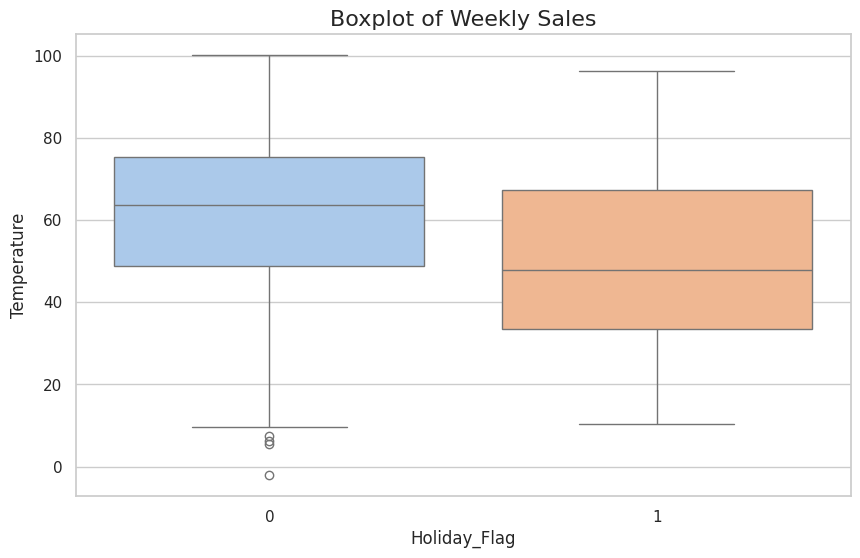

In [33]:

import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
sns.boxplot(data=df,x='Holiday_Flag',y='Temperature',palette='pastel')

plt.title('Boxplot of Weekly Sales',fontsize=16)
plt.xlabel('Holiday_Flag',fontsize=12)
plt.ylabel('Temperature',fontsize=12)

/tmp/ipykernel_14881/3510770071.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(data=df,x='Holiday_Flag',y='Temperature',palette='pastel')


Text(0, 0.5, 'Temperature')

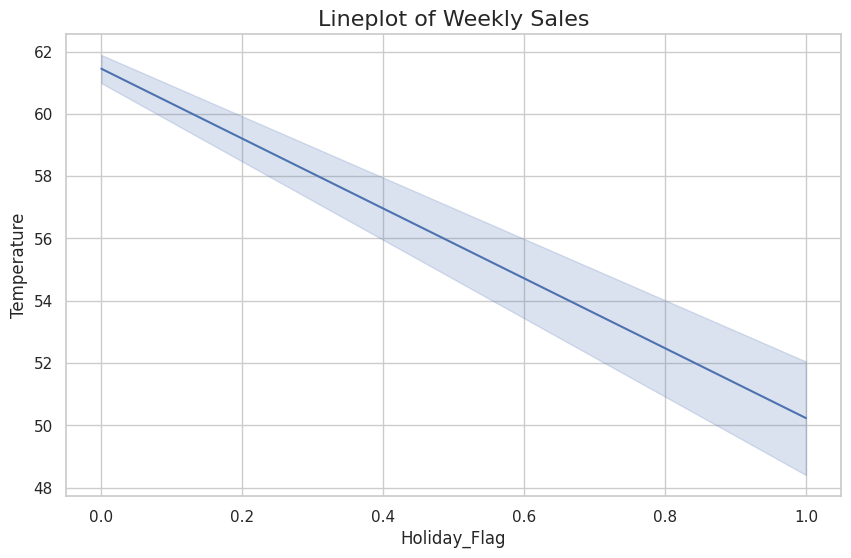

In [34]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
sns.lineplot(data=df,x='Holiday_Flag',y='Temperature',palette='pastel')

plt.title('Lineplot of Weekly Sales',fontsize=16)
plt.xlabel('Holiday_Flag',fontsize=12)
plt.ylabel('Temperature',fontsize=12)

/tmp/ipykernel_14881/635958907.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data=df,x='Holiday_Flag',y='CPI',palette='pastel')


Text(0, 0.5, 'Temperature')

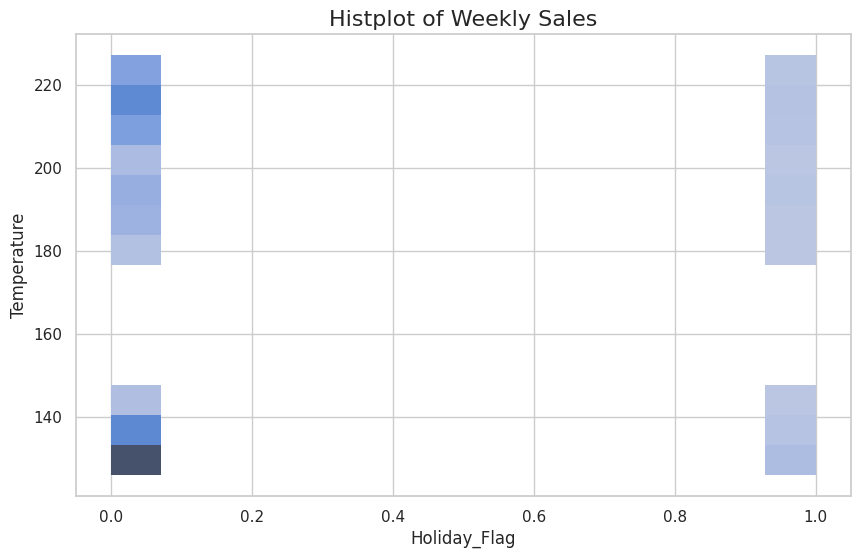

In [35]:

import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
sns.histplot(data=df,x='Holiday_Flag',y='CPI',palette='pastel')

plt.title('Histplot of Weekly Sales',fontsize=16)
plt.xlabel('Holiday_Flag',fontsize=12)
plt.ylabel('Temperature',fontsize=12)

In [36]:
df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y")
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["Quarter"] = df["Date"].dt.quarter # Add Quarter feature for consistency

In [37]:
df[['Date','Month','Year']].head()

,Date,Month,Year
0,2010-02-05,2,2010
1,2010-02-12,2,2010
2,2010-02-19,2,2010
3,2010-02-26,2,2010
4,2010-03-05,3,2010


In [38]:
file_path=('/content/Walmart Data Analysis and Forcasting.csv')
df=pd.read_csv(file_path)



In [39]:
numerical_columns=['Weekly_Sales','Fuel Price']

In [40]:
from sklearn.preprocessing import MinMaxScaler
minmax_scaler=MinMaxScaler()


In [41]:
df['Weekly_Sales_MinMax']=minmax_scaler.fit_transform(df[['Weekly_Sales']])
df['Fuel_Price_MinMax']=minmax_scaler.fit_transform(df[['Fuel_Price']])

In [42]:
df[['Weekly_Sales','Weekly_Sales_MinMax']]

,Weekly_Sales,Weekly_Sales_MinMax
0,1643690.90,0.397291
1,1641957.44,0.396811
2,1611968.17,0.388501
3,1409727.59,0.332458
4,1554806.68,0.372661
...,...,...
6430,713173.95,0.139437
6431,733455.07,0.145057
6432,734464.36,0.145337
6433,718125.53,0.140810


In [43]:
df[['Fuel_Price','Fuel_Price_MinMax']]

,Fuel_Price,Fuel_Price_MinMax
0,2.572,0.050100
1,2.548,0.038076
2,2.514,0.021042
3,2.561,0.044589
4,2.625,0.076653
...,...,...
6430,3.997,0.764028
6431,3.985,0.758016
6432,4.000,0.765531
6433,3.969,0.750000


In [44]:
from scipy.stats import skew

In [45]:
df.select_dtypes(include=np.number).skew()

,0
Store,0.000000
Weekly_Sales,0.668362
Holiday_Flag,3.373499
Temperature,-0.336768
Fuel_Price,-0.096158
CPI,0.063492
Unemployment,1.188144
Weekly_Sales_MinMax,0.668362
Fuel_Price_MinMax,-0.096158


In [46]:
import numpy as np
# Recalculate skewed columns based on the current DataFrame
skewed_cols=df.select_dtypes(include=np.number).skew().abs()
highly_skewed=skewed_cols[skewed_cols>1].index
negatively_skewed=skewed_cols[skewed_cols<1].index
print("Highly Skewed Columns:\n",highly_skewed)
print("Negatively Skewed Columns:\n",negatively_skewed)

Highly Skewed Columns:
 Index(['Holiday_Flag', 'Unemployment'], dtype='object')
Negatively Skewed Columns:
 Index(['Store', 'Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI',
       'Weekly_Sales_MinMax', 'Fuel_Price_MinMax'],
      dtype='object')


In [47]:
from sklearn.preprocessing import PowerTransformer
pt=PowerTransformer(method='yeo-johnson')

# Filter negatively_skewed columns to exclude target and its derivatives for transformation
# Ensure only columns that are actual features are transformed
features_for_pt = [col for col in negatively_skewed if col not in ['Weekly_Sales', 'Weekly_Sales_MinMax']]

# Apply power transformation only to these selected features in df
df[features_for_pt]=pt.fit_transform(df[features_for_pt])

In [48]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Define features (X) and target (y)
# Drop 'Weekly_Sales' (the target itself), 'Date', and any columns directly derived from 'Weekly_Sales'
X = df.drop(columns=["Weekly_Sales","Date", "Weekly_Sales_MinMax"])
y = df["Weekly_Sales"]

# Split the dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Model Evaluation
r2 = r2_score(y_test, y_pred)
#rmse = mean_squared_error(y_test, y_pred, squared=False)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R² Score: 0.1413
RMSE: 525968.4727


<function matplotlib.pyplot.show(close=None, block=None)>

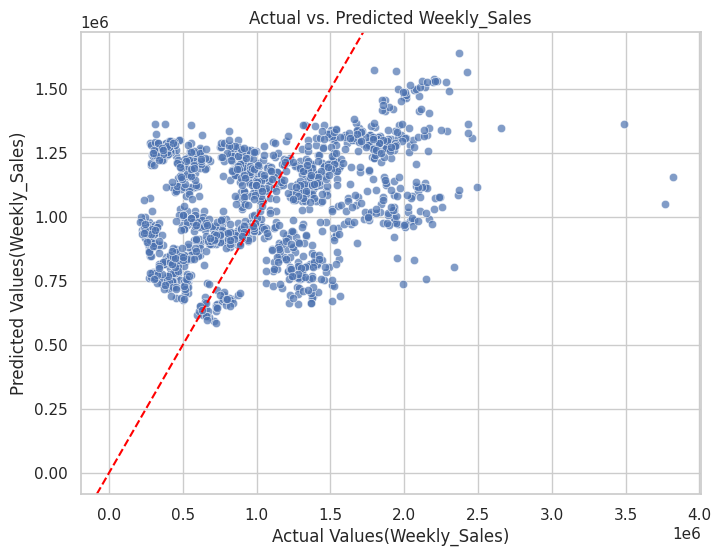

In [49]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test,y=y_pred,alpha=0.7)
plt.xlabel('Actual Values(Weekly_Sales)')
plt.ylabel('Predicted Values(Weekly_Sales)')
plt.title('Actual vs. Predicted Weekly_Sales')
plt.axline([0,0],[1,1],color="red",linestyle="--")
plt.show



In [52]:
from scipy.stats import skew

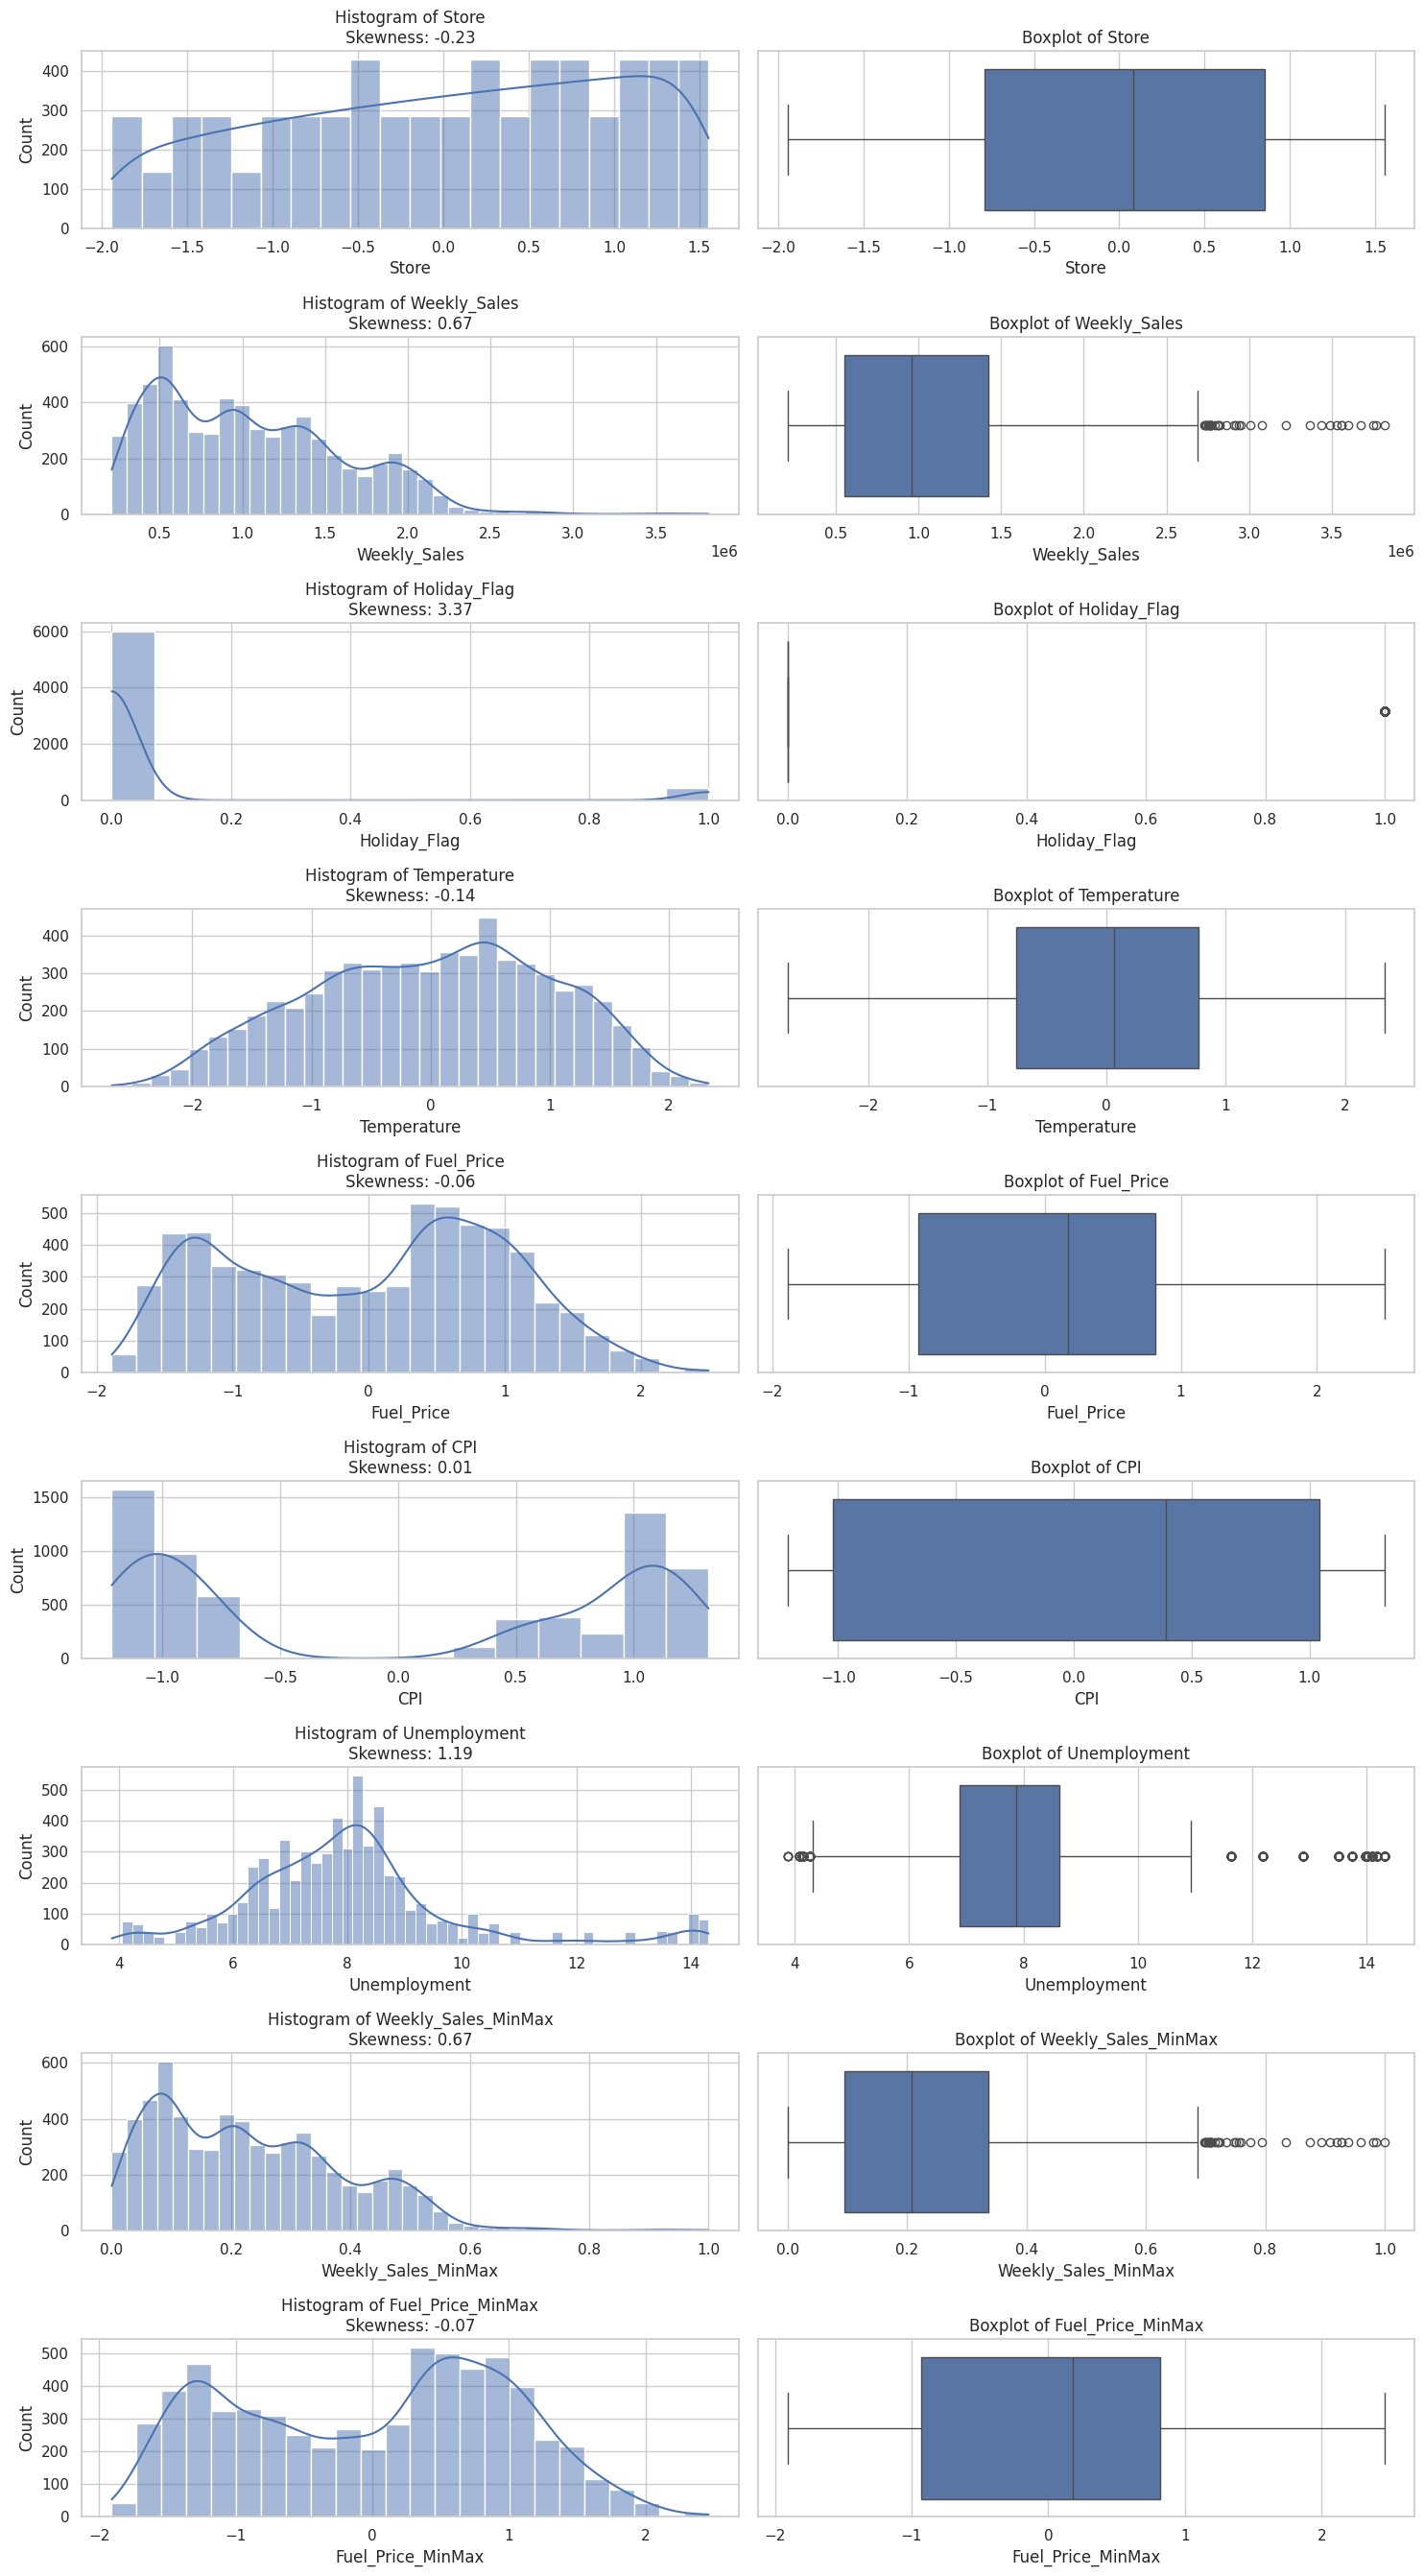

In [53]:
numeric_df = df.select_dtypes(include=np.number)
skewness = numeric_df.skew()
num_numeric_cols = len(numeric_df.columns)

plt.figure(figsize=(15, num_numeric_cols * 3))
for i, col in enumerate(numeric_df.columns):
    plt.subplot(num_numeric_cols, 2, 2 * i + 1)
    sns.histplot(numeric_df[col], kde=True)
    plt.title(f'Histogram of {col}\nSkewness: {skewness[col]:.2f}')
    plt.subplot(num_numeric_cols, 2, 2 * i + 2)
    sns.boxplot(x=numeric_df[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

In [56]:
skewness = df.select_dtypes(include=np.number).skew()
print(skewness)

Store                 -0.228157
Weekly_Sales           0.668362
Holiday_Flag           3.373499
Temperature           -0.141684
Fuel_Price            -0.055815
CPI                    0.010477
Unemployment           1.188144
Weekly_Sales_MinMax    0.668362
Fuel_Price_MinMax     -0.073724
dtype: float64


In [58]:
import numpy as np
skewed_cols=df.select_dtypes(include=np.number).skew().abs()
highly_skewed=skewed_cols[skewed_cols>1].index
negatively_skewed=skewed_cols[skewed_cols<1].index
print("Highly Skewed Columns:\n",highly_skewed)
print("Negatively Skewed Columns:\n",negatively_skewed)

Highly Skewed Columns:
 Index(['Holiday_Flag', 'Unemployment'], dtype='object')
Negatively Skewed Columns:
 Index(['Store', 'Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI',
       'Weekly_Sales_MinMax', 'Fuel_Price_MinMax'],
      dtype='object')


In [59]:
df[highly_skewed]=df[highly_skewed].apply(lambda x:np.log1p(x))

In [60]:
from sklearn.preprocessing import PowerTransformer
pt=PowerTransformer(method='yeo-johnson')
df[negatively_skewed]=pt.fit_transform(df[negatively_skewed])

In [63]:
df.select_dtypes(include=np.number).skew()

,0
Store,-0.043855
Weekly_Sales,-0.049912
Holiday_Flag,3.373499
Temperature,-0.011073
Fuel_Price,0.015640
CPI,0.009450
Unemployment,0.226991
Weekly_Sales_MinMax,0.070616
Fuel_Price_MinMax,0.011494


In [64]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Define features (X) and target (y)
# Drop 'Weekly_Sales' (the target itself), 'Date', and any columns directly derived from 'Weekly_Sales'
X = df.drop(columns=["Weekly_Sales","Date", "Weekly_Sales_MinMax"])
y = df["Weekly_Sales"]

# Split the dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Model Evaluation
r2 = r2_score(y_test, y_pred)
#rmse = mean_squared_error(y_test, y_pred, squared=False)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R² Score: 0.1310
RMSE: 0.9442


<function matplotlib.pyplot.show(close=None, block=None)>

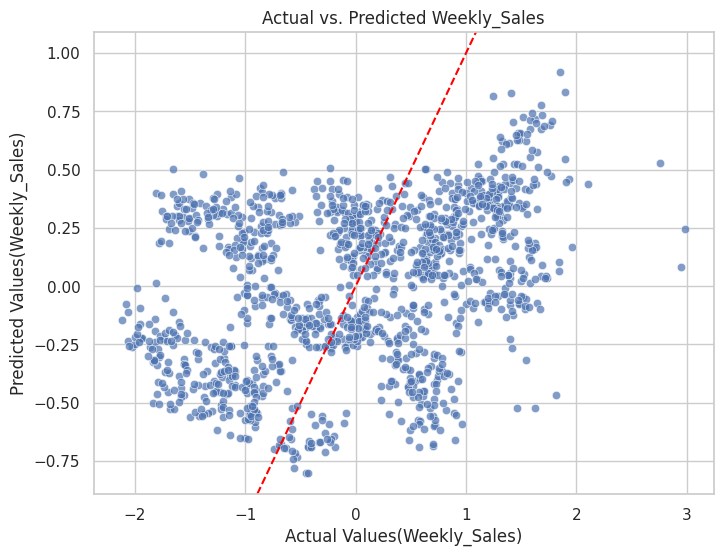

In [65]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test,y=y_pred,alpha=0.7)
plt.xlabel('Actual Values(Weekly_Sales)')
plt.ylabel('Predicted Values(Weekly_Sales)')
plt.title('Actual vs. Predicted Weekly_Sales')
plt.axline([0,0],[1,1],color="red",linestyle="--")
plt.show

